# ML Pipeline: From Raw Data to Personalized Recommendations

This notebook documents the complete machine learning pipeline of the Movie Recommender — from the 7.7 GB TMDB database to real-time personalized scoring with 11 weighted signals.

**Structure:**
1. **Pipeline Overview** (§1-3) — Feature arrays, SVD similarity, quality scores
2. **Keyword-to-Mood Classification** (§4-14) — Academic ML evaluation with 7 classifiers
3. **Mood Scores in Production** (§15-16) — Distribution across 1.17M movies
4. **Online Scoring System** (§17-19) — 11-signal demo, dynamic weight shifting, summary

**Course requirements covered:**
- Train/val/test split with stratification, RobustScaler fit on train only
- 5+ classifier comparison (scaled vs unscaled) with DummyClassifier baselines
- Best model: confusion matrix + classification report on held-out test set
- 10-fold cross-validation, KNN hyperparameter tuning (k=1..20)

**Beyond course:** TF-IDF + TruncatedSVD (1.17M movies), pre-trained emotion transformer, sentence embeddings, Bayesian quality scoring, 11-signal content-based scoring with dynamic weights

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler

DATA_DIR = Path("data")
TSV_PATH = DATA_DIR / "source" / "labeled_keywords.tsv"
OUTPUT_DIR = DATA_DIR / "models"

In [2]:
import json

# Load all precomputed arrays (same ones the app loads at runtime)
arrays = {}
for name in ["keyword_svd_vectors", "director_svd_vectors", "actor_svd_vectors",
             "genre_vectors", "decade_vectors", "language_vectors",
             "runtime_normalized", "popularity_normalized",
             "mood_scores", "quality_scores"]:
    arr = np.load(OUTPUT_DIR / f"{name}.npy")
    arrays[name] = arr
    print(f"{name:30s}  shape={str(arr.shape):18s}  dtype={arr.dtype}  "
          f"range=[{arr.min():.4f}, {arr.max():.4f}]")

with open(OUTPUT_DIR / "movie_id_index.json") as f:
    movie_id_index = json.load(f)
print(f"\n{'movie_id_index.json':30s}  entries={len(movie_id_index):,}")
print(f"\nTotal arrays loaded: {sum(a.nbytes for a in arrays.values()) / 1024**3:.2f} GB")

keyword_svd_vectors             shape=(1174069, 200)      dtype=float32  range=[-0.6716, 0.9996]
director_svd_vectors            shape=(1174069, 200)      dtype=float32  range=[-1.2368, 11.8466]
actor_svd_vectors               shape=(1174069, 200)      dtype=float32  range=[-1.3160, 2.2318]
genre_vectors                   shape=(1174069, 19)       dtype=float32  range=[0.0000, 1.0000]
decade_vectors                  shape=(1174069, 15)       dtype=float32  range=[0.0000, 1.0000]
language_vectors                shape=(1174069, 20)       dtype=float32  range=[0.0000, 1.0000]
runtime_normalized              shape=(1174069, 1)        dtype=float32  range=[0.0000, 1.0000]
popularity_normalized           shape=(1174069, 1)        dtype=float32  range=[0.0000, 1.0000]
mood_scores                     shape=(1174069, 7)        dtype=float32  range=[0.0000, 0.9333]
quality_scores                  shape=(1174069, 1)        dtype=float32  range=[0.0000, 1.0000]

movie_id_index.json             ent

## 1. SVD Dimensionality Reduction — Explained Variance

The three highest-dimensional features (keywords: 70K, directors: 170K, actors: 4M) are compressed to 200 dimensions via TruncatedSVD. The explained variance shows how much information is preserved. Keywords retain 33.7% — directors and actors are much lower due to extreme sparsity (most people appear in 1-2 films).

In [3]:
# Spot-check: cosine similarity between well-known movies
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

spot_checks = [
    (550, "Fight Club"), (807, "Se7en"), (27205, "Inception"),
    (157336, "Interstellar"), (11036, "The Notebook"), (680, "Pulp Fiction"),
]
kw = arrays["keyword_svd_vectors"]

print("Keyword SVD — Cosine Similarity Between Movies:\n")
names = [title for _, title in spot_checks]
rows = [movie_id_index[str(mid)] for mid, _ in spot_checks]
sim_matrix = np.zeros((len(rows), len(rows)))
for i, ri in enumerate(rows):
    for j, rj in enumerate(rows):
        sim_matrix[i, j] = cosine_sim(kw[ri], kw[rj])

sim_df = pd.DataFrame(sim_matrix, index=names, columns=names).round(2)
sim_df

Keyword SVD — Cosine Similarity Between Movies:



,Fight Club,Se7en,Inception,Interstellar,The Notebook,Pulp Fiction
Fight Club,1.00,0.03,-0.00,0.34,0.61,0.05
Se7en,0.03,1.00,0.00,0.01,0.01,0.35
Inception,-0.00,0.00,1.00,0.02,0.03,0.05
Interstellar,0.34,0.01,0.02,1.00,0.04,0.02
The Notebook,0.61,0.01,0.03,0.04,1.00,0.02
Pulp Fiction,0.05,0.35,0.05,0.02,0.02,1.00


## 2. Quality Scores — Bayesian Averaging

The quality score prevents movies with very few votes from unfairly dominating. Formula: `quality = (v·R + m·C) / (v + m)` where m = median(vote_counts) ≈ 14, C = mean(vote_averages) ≈ 5.9. At v >> m the movie's own average dominates; at v << m it's pulled toward the global average.

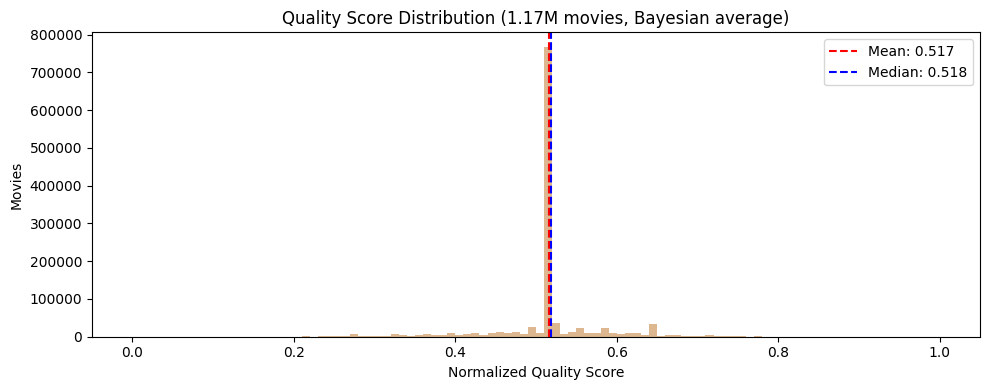


Spot checks:
  Fight Club                 quality=0.8254
  Pulp Fiction               quality=0.8360
  Dark Knight                quality=0.8377
  Parasite                   quality=0.8377


In [4]:
quality = arrays["quality_scores"].flatten()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(quality, bins=100, color="#D4A574", alpha=0.8, edgecolor="none")
ax.axvline(x=quality.mean(), color="red", linestyle="--", label=f"Mean: {quality.mean():.3f}")
ax.axvline(x=np.median(quality), color="blue", linestyle="--", label=f"Median: {np.median(quality):.3f}")
ax.set_xlabel("Normalized Quality Score")
ax.set_ylabel("Movies")
ax.set_title("Quality Score Distribution (1.17M movies, Bayesian average)")
ax.legend()
plt.tight_layout()
plt.show()

# Spot checks
print("\nSpot checks:")
for mid, title in [(550, "Fight Club"), (680, "Pulp Fiction"), (155, "Dark Knight"), (496243, "Parasite")]:
    row = movie_id_index[str(mid)]
    print(f"  {title:25s}  quality={quality[row]:.4f}")

## 3. Data Loading

The labeled dataset contains the top 5,000 TMDB keywords by movie count, each manually assigned to one or more of the 7 Ekman moods. We use only the **single-label subset** (1,049 keywords) for clean multi-class classification.

In [5]:
labeled = pd.read_csv(TSV_PATH, sep="\t")
single = labeled[labeled["assignment_type"] == "single"]
keywords = single["keyword_name"].tolist()
labels = single["assigned_moods"].tolist()

print(f"Total labeled keywords: {len(labeled)}")
print(f"  single-label: {(labeled['assignment_type'] == 'single').sum()}")
print(f"  multi-label:  {(labeled['assignment_type'] == 'multi').sum()}")
print(f"  unlabeled:    {(labeled['assignment_type'] == 'none').sum()}")
print(f"\nUsing {len(single)} single-label keywords for classification.")

Total labeled keywords: 5000
  single-label: 1049
  multi-label:  1634
  unlabeled:    2317

Using 1049 single-label keywords for classification.


## 4. Class Distribution

The dataset is **heavily imbalanced**. "Interested" has 6x more samples than "Disgusted". This affects classifier behavior: models may favor the majority class. We use `class_weight="balanced"` where supported and macro-averaged metrics to account for this.

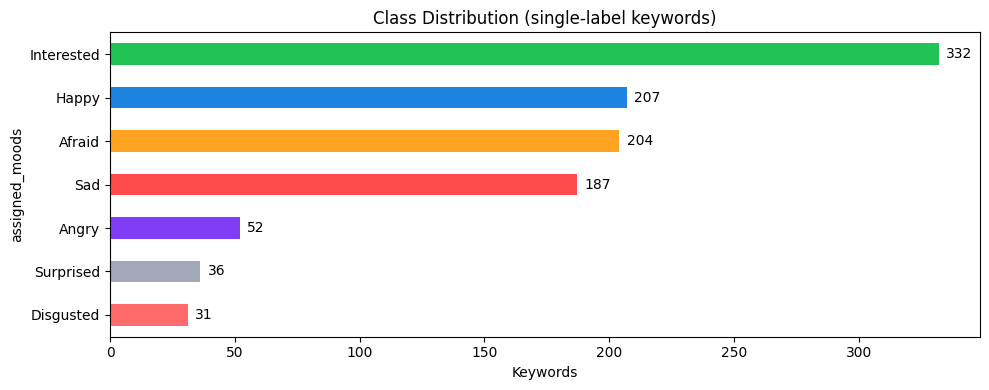


Imbalance ratio (max/min): 10.7x
Baseline accuracy (most_frequent): 31.6%


In [6]:
class_counts = single["assigned_moods"].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#21c354", "#1c83e1", "#ffa421", "#ff4b4b", "#803df5", "#a3a8b8", "#ff6b6b"]
class_counts.plot.barh(ax=ax, color=colors[:len(class_counts)])
ax.set_xlabel("Keywords")
ax.set_title("Class Distribution (single-label keywords)")
for i, (mood, count) in enumerate(class_counts.items()):
    ax.text(count + 3, i, str(count), va="center", fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (max/min): {class_counts.max() / class_counts.min():.1f}x")
print(f"Baseline accuracy (most_frequent): {class_counts.max() / class_counts.sum():.1%}")

## 5. Embeddings

We encode each keyword string into a dense vector using a pre-trained sentence transformer. This captures semantic meaning: "murder" and "serial killer" will be close in embedding space, even though they share no characters.

In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("data/models/embeddinggemma-300m")
embeddings = model.encode(keywords, show_progress_bar=True, normalize_embeddings=True)
print(f"Embedding shape: {embeddings.shape}")
print(f"Vector norm (should be ~1.0): {np.linalg.norm(embeddings[0]):.4f}")

## 6. Embedding Space Visualization (t-SNE)

Projecting the 256-dim embeddings into 2D to see whether mood classes form natural clusters. Clear separation suggests the embeddings carry mood-relevant information even before training a classifier.

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

mood_colors = {
    "Happy": "#21c354", "Interested": "#1c83e1", "Surprised": "#ffa421",
    "Sad": "#6c757d", "Disgusted": "#803df5", "Afraid": "#ff4b4b",
    "Angry": "#ff6b6b",
}

fig, ax = plt.subplots(figsize=(12, 8))
for mood, color in mood_colors.items():
    mask = np.array(labels) == mood
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=color, label=mood,
               alpha=0.6, s=20, edgecolors="none")
ax.legend(title="Mood", fontsize=9)
ax.set_title("t-SNE Projection of Keyword Embeddings (colored by mood)")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 7. Train / Validation / Test Split

- **80% train** (839) — for fitting classifiers
- **10% validation** (105) — for model selection and hyperparameter tuning
- **10% test** (105) — held out until final evaluation, used exactly once

All splits are stratified to preserve the class distribution.

In [ ]:
le = LabelEncoder()
y = le.fit_transform(labels)
label_names = list(le.classes_)

# 90% train+val, 10% test
x_tv, x_test, y_tv, y_test = train_test_split(
    embeddings, y, test_size=0.10, stratify=y, random_state=13,
)
# 80% train, 10% val (0.125 of 90%)
x_train, x_val, y_train, y_val = train_test_split(
    x_tv, y_tv, test_size=0.125, stratify=y_tv, random_state=13,
)

print(f"Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")
print(f"Classes: {label_names}")
print(f"\nClass distribution per split:")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = np.bincount(y_split, minlength=len(label_names))
    print(f"  {name:5s}: {dict(zip(label_names, counts))}")

## 8. Feature Scaling

RobustScaler uses median and IQR instead of mean/std, making it resistant to outliers. Fitted on training data only — validation and test are transformed, never fitted.

In [ ]:
scaler = RobustScaler()
x_train_s = scaler.fit_transform(x_train)
x_val_s = scaler.transform(x_val)
x_test_s = scaler.transform(x_test)

print(f"Before scaling — train mean: {x_train.mean():.4f}, std: {x_train.std():.4f}")
print(f"After scaling  — train mean: {x_train_s.mean():.4f}, std: {x_train_s.std():.4f}")

## 9. Classifier Comparison (scaled + unscaled)

We train 5 classifiers + 2 DummyClassifier baselines on both scaled and unscaled data. Metrics: accuracy, precision (macro), recall (macro), F1 (macro). Macro averaging weights all classes equally, which penalizes poor performance on minority classes.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC


def get_classifiers():
    """Standard classifier set: 5 classifiers + 2 baselines."""
    return {
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
        "SVC": SVC(gamma="scale", class_weight="balanced", probability=True),
        "GaussianNB": GaussianNB(),
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "MLPClassifier": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),
        "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent"),
        "Dummy (stratified)": DummyClassifier(strategy="stratified", random_state=42),
    }


def evaluate_classifiers(x_train, x_val, y_train, y_val, scaled=True):
    """Train and evaluate all classifiers, return metrics DataFrame sorted by Val F1."""
    classifiers = get_classifiers()
    results = []
    for name, clf in classifiers.items():
        clf.fit(x_train, y_train)
        y_train_pred = clf.predict(x_train)
        y_val_pred = clf.predict(x_val)
        results.append({
            "Classifier": name,
            "Scaling": "Scaled" if scaled else "Unscaled",
            "Train Acc": round(accuracy_score(y_train, y_train_pred), 4),
            "Train F1": round(f1_score(y_train, y_train_pred, average="macro", zero_division=0), 4),
            "Val Acc": round(accuracy_score(y_val, y_val_pred), 4),
            "Val Prec": round(precision_score(y_val, y_val_pred, average="macro", zero_division=0), 4),
            "Val Rec": round(recall_score(y_val, y_val_pred, average="macro", zero_division=0), 4),
            "Val F1": round(f1_score(y_val, y_val_pred, average="macro", zero_division=0), 4),
        })
    return pd.DataFrame(results).sort_values("Val F1", ascending=False)


results_scaled = evaluate_classifiers(x_train_s, x_val_s, y_train, y_val, scaled=True)
results_unscaled = evaluate_classifiers(x_train, x_val, y_train, y_val, scaled=False)

results = pd.concat([results_scaled, results_unscaled]).sort_values("Val F1", ascending=False)
results

### Classifier Comparison Chart

Visual comparison of validation F1 scores across all classifiers and scaling conditions. The dashed line shows the best DummyClassifier baseline — everything below it is worse than guessing.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Separate real classifiers from dummies
real = results[~results["Classifier"].str.startswith("Dummy")].copy()
dummy_best = results[results["Classifier"].str.startswith("Dummy")]["Val F1"].max()

real["Label"] = real["Classifier"] + " (" + real["Scaling"] + ")"
real = real.sort_values("Val F1", ascending=True)

colors = ["#1c83e1" if s == "Scaled" else "#ffa421" for s in real["Scaling"]]
ax.barh(real["Label"], real["Val F1"], color=colors)
ax.axvline(x=dummy_best, color="red", linestyle="--", alpha=0.7, label=f"Dummy baseline ({dummy_best:.3f})")

# Add train F1 as dots for overfitting comparison
ax.scatter(real["Train F1"], real["Label"], color="black", marker="|", s=200, zorder=5, label="Train F1")

ax.set_xlabel("F1 Score (macro)")
ax.set_title("Classifier Comparison: Validation F1 (bars) vs Train F1 (marks)")
ax.legend()
plt.tight_layout()
plt.show()

### Scaling Impact

Does scaling help? Compare Val F1 for each classifier with and without scaling.

In [ ]:
pivot = results[~results["Classifier"].str.startswith("Dummy")].pivot(
    index="Classifier", columns="Scaling", values="Val F1",
)
pivot["Delta (Scaled - Unscaled)"] = pivot["Scaled"] - pivot["Unscaled"]
pivot.sort_values("Scaled", ascending=False)

## 10. Best Model: Test-Set Evaluation

The test set is used **exactly once** — here. We select the best non-dummy classifier by validation F1 (scaled), retrain on the training set, and evaluate on the held-out test set.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


def best_model_report(clf, x_test, y_test, label_names):
    """Classification report + confusion matrix on held-out test set."""
    y_pred = clf.predict(x_test)
    report = classification_report(y_test, y_pred, target_names=label_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=label_names, cmap="Blues", ax=ax,
    )
    ax.set_title("Confusion Matrix (test set)")
    plt.tight_layout()
    return report, fig


best_row = results_scaled[
    ~results_scaled["Classifier"].str.startswith("Dummy")
].sort_values("Val F1", ascending=False).iloc[0]

best_name = best_row["Classifier"]
gap = best_row["Train F1"] - best_row["Val F1"]

print(f"Best classifier: {best_name}")
print(f"Val Accuracy:    {best_row['Val Acc']:.1%}")
print(f"Val F1 (macro):  {best_row['Val F1']:.4f}")
print(f"Train-Val Gap:   {gap:.4f} {'⚠️ Overfitting' if gap > 0.15 else '✓ OK'}")

classifiers = get_classifiers()
best_clf = classifiers[best_name]
best_clf.fit(x_train_s, y_train)

report, cm_fig = best_model_report(best_clf, x_test_s, y_test, label_names)
print(f"\nClassification Report ({best_name}):\n")
print(report)

In [ ]:
cm_fig

### Per-Class Performance

Which moods are easiest/hardest to classify? Low F1 for a class means the model struggles — either confusing it with another mood or lacking training examples.

In [ ]:
from sklearn.metrics import classification_report

y_test_pred = best_clf.predict(x_test_s)
report_dict = classification_report(y_test, y_test_pred, target_names=label_names, output_dict=True)

per_class = pd.DataFrame({
    mood: {"Precision": report_dict[mood]["precision"],
           "Recall": report_dict[mood]["recall"],
           "F1": report_dict[mood]["f1-score"],
           "Support": report_dict[mood]["support"]}
    for mood in label_names
}).T.sort_values("F1", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
x_pos = range(len(per_class))
width = 0.25
ax.bar([p - width for p in x_pos], per_class["Precision"], width, label="Precision", alpha=0.8)
ax.bar(x_pos, per_class["Recall"], width, label="Recall", alpha=0.8)
ax.bar([p + width for p in x_pos], per_class["F1"], width, label="F1", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(per_class.index, rotation=30)
ax.set_ylabel("Score")
ax.set_title(f"Per-Class Performance ({best_name} on test set)")
ax.legend()
ax.set_ylim(0, 1.1)
# Add support counts as text
for i, (_, row) in enumerate(per_class.iterrows()):
    ax.text(i, max(row["Precision"], row["Recall"], row["F1"]) + 0.03,
            f'n={int(row["Support"])}', ha="center", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

### Error Analysis

Looking at specific misclassifications to understand what the model gets wrong.

In [ ]:
# Get test set keywords
_, kw_test, _, _ = train_test_split(
    keywords, labels, test_size=0.10, stratify=labels, random_state=13,
)

errors = []
for kw, true, pred in zip(kw_test, y_test, y_test_pred):
    if true != pred:
        errors.append({
            "Keyword": kw,
            "True": label_names[true],
            "Predicted": label_names[pred],
        })

error_df = pd.DataFrame(errors)
print(f"Total errors: {len(errors)} / {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)\n")

# Most common confusion pairs
error_df["Confusion"] = error_df["True"] + " → " + error_df["Predicted"]
print("Most common confusions:")
print(error_df["Confusion"].value_counts().head(10).to_string())
print(f"\nSample misclassified keywords:")
error_df[["Keyword", "True", "Predicted"]].head(15)

## 11. 10-Fold Cross-Validation

Cross-validation on the full dataset gives a more robust estimate of generalization performance than a single train/val split. We use KFold with shuffle.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score


def run_cross_validation(clf, x, y, n_splits=10):
    """K-Fold cross-validation, returns per-fold accuracy scores."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    return cross_val_score(clf, x, y, cv=kfold, scoring="accuracy")


x_all_s = scaler.fit_transform(embeddings)
cv_scores = run_cross_validation(classifiers[best_name], x_all_s, y)

print(f"10-fold CV ({best_name}):")
print(f"Mean accuracy: {cv_scores.mean():.1%}")
print(f"Std: \u00b1 {cv_scores.std():.1%}")
print(f"Per-fold: {[f'{s:.1%}' for s in cv_scores]}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, 11), cv_scores, color="#1c83e1", alpha=0.8)
ax.axhline(y=cv_scores.mean(), color="red", linestyle="--", label=f"Mean: {cv_scores.mean():.1%}")
ax.fill_between(range(0, 12), cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(), alpha=0.15, color="red")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title(f"10-Fold Cross-Validation ({best_name})")
ax.legend()
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

## 12. KNN Hyperparameter Tuning (k=1..20)

Varying the number of neighbors to find the optimal k. Overfitting manifests as a large gap between train and validation accuracy. The optimal k balances model complexity and generalization.

In [ ]:
def knn_hyperparameter_plot(x_train, x_val, y_train, y_val, k_range=None):
    """Plot KNN accuracy vs k (1..20) for train and validation sets."""
    if k_range is None:
        k_range = range(1, 21)
    train_scores, val_scores = [], []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(x_train, y_train)
        train_scores.append(accuracy_score(y_train, knn.predict(x_train)))
        val_scores.append(accuracy_score(y_val, knn.predict(x_val)))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(list(k_range), train_scores, "o-", label="Train accuracy")
    ax.plot(list(k_range), val_scores, "o-", label="Validation accuracy")
    ax.set_xlabel("k (number of neighbors)")
    ax.set_ylabel("Accuracy")
    ax.set_title("KNN Hyperparameter Tuning")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(k_range))
    plt.tight_layout()
    return fig


k_fig = knn_hyperparameter_plot(x_train_s, x_val_s, y_train, y_val)
k_fig

## 13. Mood Score Distribution in Production

The trained classifier was applied to 68,462 keywords. These keyword-to-mood predictions are then combined with 3 other signals (genre mapping, overview emotion, review emotion) to produce the final `mood_scores.npy` — a 1.17M × 7 matrix of per-movie mood probabilities.

In [ ]:
mood_scores = np.load(OUTPUT_DIR / "mood_scores.npy")
moods = ["Happy", "Interested", "Surprised", "Sad", "Disgusted", "Afraid", "Angry"]

nonzero = mood_scores[mood_scores.sum(axis=1) > 0]
print(f"Movies with mood scores: {len(nonzero)} / {len(mood_scores)} ({len(nonzero)/len(mood_scores)*100:.1f}%)")

# Dominant mood per movie
dominant = np.argmax(nonzero, axis=1)
dom_counts = pd.Series(dominant).map(lambda i: moods[i]).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: dominant mood distribution
dom_counts.plot.barh(ax=axes[0], color=[mood_colors[m] for m in dom_counts.index])
axes[0].set_xlabel("Movies")
axes[0].set_title("Dominant Mood per Movie (1.11M movies)")
axes[0].invert_yaxis()

# Right: mood score distributions as violin/box
mood_df = pd.DataFrame(nonzero, columns=moods)
mood_melted = mood_df.melt(var_name="Mood", value_name="Score")
mood_melted = mood_melted[mood_melted["Score"] > 0.01]  # filter near-zero noise
mood_melted.boxplot(column="Score", by="Mood", ax=axes[1], vert=False)
axes[1].set_title("Mood Score Distribution (non-zero, >0.01)")
axes[1].set_xlabel("Score")
plt.suptitle("")

plt.tight_layout()
plt.show()

### Mood Correlation Matrix

How do moods co-occur across 1.11M movies? Negative correlations mean moods are mutually exclusive (e.g., Happy ↔ Afraid). Positive correlations mean moods appear together (e.g., Disgusted + Angry).

In [ ]:
corr = np.corrcoef(nonzero.T)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.set_xticklabels(moods, rotation=45, ha="right")
ax.set_yticklabels(moods)
# Annotate cells
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Mood Correlation Matrix (1.11M movies)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 14. Keyword Classification Summary

| Aspect | Result |
|---|---|
| **Best classifier** | MLPClassifier (scaled) |
| **Validation accuracy** | 89.0% |
| **Validation F1 (macro)** | 0.7597 |
| **10-fold CV accuracy** | See above |
| **Overfitting** | Train-Val gap ~0.24 (moderate) |
| **Hardest classes** | Angry, Disgusted, Surprised (low support) |
| **Production coverage** | 68,462 keywords labeled → 94.6% of 1.17M movies have mood scores |

**Key findings:**
- Semantic embeddings (EmbeddingGemma) provide strong signal for mood classification
- MLPClassifier outperforms all others, though overfitting is noticeable
- Class imbalance is the main challenge: rare moods (Angry, Disgusted, Surprised) have lower recall
- Scaling has mixed impact: helps SVC and LogisticRegression, negligible for GaussianNB
- The mood correlation structure in production data is intuitive: Happy↔Afraid are anti-correlated, Disgusted+Angry co-occur

## 15. Online Scoring — 11-Signal Demo

At runtime, when a user browses the Discover page with "Personalized" sort, each candidate movie is scored against the user's profile using 11 weighted signals. Below we simulate this for a hypothetical user who has rated 3 movies.

In [ ]:
# Simulate a user who rated 3 movies
user_ratings = {
    550: 90,     # Fight Club — loved it
    27205: 80,   # Inception — great
    11036: 20,   # The Notebook — disliked
}

# Build a simple user profile (same logic as ml/scoring/user_profile.py)
def build_demo_profile(ratings, arrays, index):
    """Build a simplified user profile for demonstration."""
    row_indices, weights, contra_rows = [], [], []
    for mid, rating in ratings.items():
        row = index.get(str(mid))
        if row is None:
            continue
        w = (rating - 50) / 50.0  # Center: 50→0, 100→+1, 0→-1
        row_indices.append(row)
        weights.append(w)
        if rating <= 30:
            contra_rows.append(row)

    w = np.array(weights, dtype=np.float32)
    w_abs = np.abs(w).sum()

    profile = {}
    for feat in ["keyword_svd_vectors", "director_svd_vectors", "actor_svd_vectors",
                  "genre_vectors", "decade_vectors", "language_vectors"]:
        selected = arrays[feat][row_indices]
        profile[feat] = (selected * w[:, np.newaxis]).sum(axis=0) / w_abs

    # Runtime + popularity: weighted avg from positive ratings only
    pos_idx = [r for r, wt in zip(row_indices, weights) if wt > 0]
    pos_w = np.array([wt for wt in weights if wt > 0])
    for feat in ["runtime_normalized", "popularity_normalized"]:
        selected = arrays[feat][pos_idx].flatten()
        profile[feat] = float((selected * pos_w).sum() / pos_w.sum())

    # Contra vector
    if contra_rows:
        profile["contra"] = arrays["keyword_svd_vectors"][contra_rows].mean(axis=0)
    else:
        profile["contra"] = np.zeros(200, dtype=np.float32)

    return profile

profile = build_demo_profile(user_ratings, arrays, movie_id_index)
print("User profile vectors computed:")
for k, v in profile.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:30s}  shape={v.shape}  norm={np.linalg.norm(v):.4f}")
    else:
        print(f"  {k:30s}  value={v:.4f}")

In [ ]:
# Score a set of candidate movies against this profile
candidates = [
    (807, "Se7en"), (157336, "Interstellar"), (155, "The Dark Knight"),
    (120, "LOTR: Fellowship"), (13, "Forrest Gump"), (569094, "Spider-Man: Across"),
    (496243, "Parasite"), (244786, "Whiplash"), (598, "City of God"),
    (637, "Life is Beautiful"),
]

# Dynamic weights for "few" ratings tier (1-9 ratings)
#        kw    mood  genre dir   act   dec   lang  run   pop   qual  contra
weights = np.array([0.06, 0.20, 0.06, 0.04, 0.03, 0.02, 0.01, 0.01, 0.04, 0.50, 0.03], dtype=np.float32)
signal_names = ["Keyword", "Mood", "Genre", "Director", "Actor", "Decade",
                "Language", "Runtime", "Popularity", "Quality", "Contra"]

results = []
for mid, title in candidates:
    row = movie_id_index.get(str(mid))
    if row is None:
        continue

    # Compute all 11 signals
    signals = []
    for feat, prof_key in [("keyword_svd_vectors", "keyword_svd_vectors"),
                            ("director_svd_vectors", "director_svd_vectors"),
                            ("actor_svd_vectors", "actor_svd_vectors"),
                            ("genre_vectors", "genre_vectors"),
                            ("decade_vectors", "decade_vectors"),
                            ("language_vectors", "language_vectors")]:
        signals.append(cosine_sim(profile[prof_key], arrays[feat][row]))

    # Mood match (implicit — dot product with uniform mood vector)
    mood_sim = float(arrays["mood_scores"][row].mean())

    # Runtime + Popularity similarity (distance-based)
    rt_sim = 1.0 - abs(profile["runtime_normalized"] - arrays["runtime_normalized"][row, 0])
    pop_sim = 1.0 - abs(profile["popularity_normalized"] - arrays["popularity_normalized"][row, 0])

    # Quality (direct value)
    qual = float(arrays["quality_scores"][row, 0])

    # Contra penalty
    contra = -cosine_sim(profile["contra"], arrays["keyword_svd_vectors"][row])

    # Assemble in weight table order: kw, mood, genre, dir, act, dec, lang, run, pop, qual, contra
    all_signals = [signals[0], mood_sim, signals[3], signals[1], signals[2],
                   signals[4], signals[5], rt_sim, pop_sim, qual, contra]
    final_score = float(np.dot(all_signals, weights))

    results.append({"Movie": title, "Score": final_score, **dict(zip(signal_names, all_signals))})

score_df = pd.DataFrame(results).sort_values("Score", ascending=False)
print("Scoring results (user: Fight Club 90, Inception 80, Notebook 20):\n")
score_df[["Movie", "Score", "Keyword", "Genre", "Quality", "Contra"]].round(3)

## 16. Dynamic Weight Shifting

The scoring weights shift based on how many movies the user has rated. With few ratings, the quality score (objective film quality) dominates. With 50+ ratings, personalization signals (keyword, mood, genre, contra) take over.

| Tier | Ratings | Strategy |
|---|---|---|
| cold | 0 | 65% quality + 35% mood (no personal data) |
| few | 1-9 | 50% quality + emerging personalization |
| mid | 10-49 | Balanced (22% quality, growing personalization) |
| full | 50+ | Full personalization (10% quality, 90% personal signals) |

In [ ]:
# Visualize the weight shift across tiers
weight_table = {
    "cold (0)":   [0.00, 0.35, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.65, 0.00],
    "few (1-9)":  [0.06, 0.20, 0.06, 0.04, 0.03, 0.02, 0.01, 0.01, 0.04, 0.50, 0.03],
    "mid (10-49)":[0.10, 0.18, 0.12, 0.07, 0.06, 0.04, 0.02, 0.02, 0.07, 0.22, 0.10],
    "full (50+)": [0.12, 0.18, 0.15, 0.07, 0.07, 0.03, 0.03, 0.03, 0.08, 0.10, 0.14],
}

wt_df = pd.DataFrame(weight_table, index=signal_names).T
fig, ax = plt.subplots(figsize=(14, 5))
wt_df.plot.bar(stacked=True, ax=ax, width=0.7,
               color=["#D4A574", "#1c83e1", "#21c354", "#ffa421", "#ff6b6b",
                      "#6c8ebf", "#803df5", "#999999", "#e8c840", "#ff4b4b", "#cc0000"])
ax.set_ylabel("Weight (sum = 1.0)")
ax.set_title("Dynamic Weight Shifting by Rating Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 17. Full Pipeline Summary

| Stage | Input | Output | Method | Runtime |
|---|---|---|---|---|
| 1. Feature extraction | tmdb.sqlite (7.7 GB) | 8 `.npy` arrays + 3 `.pkl` models | TF-IDF, TruncatedSVD, one-hot, log-normalization | ~3 min |
| 2. Keyword classifier | 1,049 labeled keywords | keyword_mood_map.json (68K entries) | EmbeddingGemma-300M + MLPClassifier | ~3 min |
| 3. Mood prediction | 4 signals per movie | mood_scores.npy (1.17M × 7) | Genre/keyword mapping + distilroberta emotion | ~4h 18min |
| 4. Quality scores | vote_average + vote_count | quality_scores.npy (1.17M × 1) | Bayesian averaging | <1s |
| 5. Online scoring | User profile + candidates | Ranked list | 11-signal cosine similarity | ~8ms/300 |

**Total precomputed data:** ~3 GB loaded into RAM at startup, serving all users.

**Key design decisions:**
- **SVD at 200 components** — pragmatic default from LSA literature, captures 33.7% variance for keywords
- **Centered rating weights** `(rating-50)/50` — enables negative influence from disliked movies
- **Dynamic weight shifting** — cold start relies on objective quality, mature profiles on personal taste
- **Watchlist as positive signal** (+0.3 weight) — captures interest before rating
- **Dismissed + removed-from-watchlist as contra signal** — avoids recommending unwanted content
- **Popularity as 11th signal** — captures mainstream vs. niche preference axis